In [11]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os

datadir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MultipleMeasuresTlife/NEWData/'
datadir2  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/NEWData/'
plotsdir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MultipleMeasuresTlife/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


The relaxation timescales for different amounts of stretch

In [12]:
Tau76 = [44170.0, 48050.0, 61510.0, 100060.0, 146073.33333333334, 282023.3333333333] #[36146.666666666664, 33926.666666666664, 46626.666666666664, 69095.0, 101840.0, 187186.66666666666]
Tau76Err = [6775.135914995851, 8342.92914189415, 1245.7126474432216, 19472.241781572044, 29651.828873706178, 62910.51334148283]
## NEEEDS REPLACING WITH NEW DATA

Tau102  = [30283.333333333332, 33860.0, 42693.333333333336, 67960.0, 91480.0, 167493.33333333334] #[25960.0, 29660.0, 40036.666666666664, 56945.0, 82443.33333333333, 172040.0]
Tau102Err =[5380.020652583243, 3260.306734035925, 3336.9879965155537, 3341.766000186129, 8903.441282260846, 31526.95495744695] #[1246.2209541917784, 1664.4518617250544, 3128.645429290801, 2055.383175955277, 5183.5273275594445, 11012.147837729022] 

#LifetimeOG =[13.979029737546464, 16.90890917750389, 17.958265955500785, 26.008657499727214, 33.33632723140763, 58.48978192449] #[29.09012996233026, 34.8496276205976, 35.93686399514268, 39.56199356163727, 47.091159059773595, 88.00389780778164] #
#LifetimeOGErr = [0.21102389938667765, 0.7282064006568923, 0.464551315776978, 1.059678765603151, 0.9268379309091307, 0.978211775560367]
LifetimeOG = [16.43266169 ,20.33251425,17.73810651 ,24.73333548 ,33.1258946  ,59.25860059] 
LifetimeOGErr =  [0.77185855, 0.17864447,0.688598,   1.37802383 ,1.55088175 ,1.06487754]
Tau102,Tau76 = np.divide(Tau102,10**6),np.divide(Tau76,10**6)
Tau102Err,Tau76Err = np.divide(Tau102Err,10**6),np.divide(Tau76Err,10**6)
#Tau51,Tau51Err = np.divide(Tau51,10**6),np.divide(Tau51Err,10**6)

In [13]:
cmap0 = plt.cm.get_cmap('YlOrBr') #YlOrBr
clrs1= ['#edf8b1','#7fcdbb','#2c7fb8']
clrs2=['#f7fcb9','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['#e7e1ef','#c994c7','#dd1c77']

clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','dimgrey']
#clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']
clrs1= ['grey','#7fcdbb','#2c7fb8']
clrs2=['grey','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['grey','#c994c7','#dd1c77']
clrs_div = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
clrrrs=[clrs1,clrs3,clrs2]

#'YlOrBr'
ClrsRici = ["#96a2c1ff","#999ebeff","#a697baff","#b795afff","#c996a8ff","#d398a5ff"]
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosen = ClrsRici #["#7883acff","#73457aff","#b25268ff","#d49995ff"]
ClrsOrange = ["#fed98e","#fe9929","#d95f0e","#993404"]

/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MultipleMeasuresTlife/NEWData/Turnover_Different_times.dat


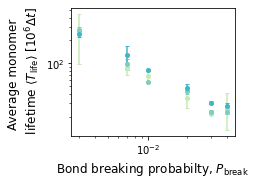

In [14]:
LifeTime0, LifeTime0Err = [], []
LifeTime1, LifeTime1Err = [], []
LifeTime2, LifeTime2Err = [], []
LifeTime3, LifeTime3Err = [], []
# LifeTime4, LifeTime4Err = [], []
fig2,ax2 = plt.subplots(1,figsize = (3.5,2.6))
filename = 'Turnover_Different_times.dat'
print(datadir+filename)
LifeTimeData = pandas.read_csv(datadir+filename, header = 'infer',sep=' ')
f=3
MP = "0.12 0.1 0.06 0.03 0.02 0.01".split() # ORIGINAL RANGE  0.12 0.1 0.06 0.03 0.02 0.01
BP = "0.04 0.03 0.02 0.01 0.007 0.003".split() # ORIGINAL RANGE 0.04 0.03 0.02 0.01 0.007 0.003
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
for i in range(len(LifeTimeData.BP)):
    if LifeTimeData.label[i]==1:
        LifeTime0.append(LifeTimeData.Turnover[i])
        LifeTime0Err.append(LifeTimeData.Error[i])
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[0],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.label[i]==2:
        LifeTime1.append(LifeTimeData.Turnover[i])
        LifeTime1Err.append(LifeTimeData.Error[i])
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[1],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.label[i]==3:
        LifeTime2.append(LifeTimeData.Turnover[i])
        LifeTime2Err.append(LifeTimeData.Error[i])
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[2],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.label[i]==4:
        LifeTime3.append(LifeTimeData.Turnover[i])
        LifeTime3Err.append(LifeTimeData.Error[i])
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[3],capsize = 2,marker = 'o',markersize = 4)
    # if LifeTimeData.label[i]==5:
    #     print("got here")
    #     LifeTime4.append(LifeTimeData.Turnover[i])
    #     LifeTime4Err.append(LifeTimeData.Error[i])
    #     ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[4],capsize = 2,marker = 'o',markersize = 4)
ax2.set_ylabel("Average monomer \n lifetime"+r" $ \langle T_{\mathrm{life}}\rangle$ [$10^6\Delta t$]",fontsize = 12)
ax2.set_xlabel("Bond breaking probabilty, $P_{\mathrm{break}}$",fontsize = 12)

fig2.tight_layout()

ax2.set_yscale('log')
ax2.set_xscale('log')
plotname = "EquilibriumMaster.pdf"
#fig2.savefig(plotsdir+plotname)



In [15]:
# truncating data
frame_OG = 2000
frame_rel = 2000 #1060
LifeTime0 = np.multiply(LifeTime0 ,frame_rel/ frame_OG )#[:-1]
LifeTime1 = np.multiply(LifeTime1,frame_rel/ frame_OG )#[:-1]
LifeTime1Err = np.multiply(LifeTime1Err,frame_rel/ frame_OG )#[:-1]
LifeTime2 = np.multiply(LifeTime2,frame_rel/ frame_OG )#[:-1]
LifeTime2Err = np.multiply(LifeTime2Err,frame_rel/ frame_OG )#[:-1]
LifeTime3 = np.multiply(LifeTime3,frame_rel/ frame_OG )#[:-1]
LifeTime3Err = np.multiply(LifeTime3Err,frame_rel/ frame_OG)
Tau102_1 = Tau102#[:-1]
Tau102Err_1 = Tau102Err#[:-1]
Tau76_1 = Tau76#[:-1]
Tau76Err_1 = Tau76Err#[:-1]

In [16]:
x1,y1 = np.array(LifetimeOG),np.array(Tau102)
m1,b1 = np.polyfit(x1,y1,1)
yfit1= m1 * x1 + b1

# R^2 calculation
ss_res = np.sum((y1 - yfit1)**2)
ss_tot = np.sum((y1 - np.mean(y1))**2)
r1_squared = 1 - (ss_res / ss_tot)
#x11 = x1.reshape(-1,1)
#a1,_,_,_ = np.linalg.lstsq(x11, y1)

x2,y2 = np.array(LifeTime0),np.array(Tau102)
print(LifeTime0)
m2,b2 = np.polyfit(x2,y2,1)
yfit2 = m2 * x2 + b2
# R^2 calculation
ss_res2 = np.sum((y2 - (yfit2))**2)
ss_tot2 = np.sum((y2 - np.mean(y2))**2)
r2_squared = 1 - (ss_res2 / ss_tot2)
#x22 = x2.reshape(-1,1)
#a2,_,_,_ = np.linalg.lstsq(x22, y2)

x3,y3 = np.array(LifeTime1),np.array(Tau102)
m3,b3 = np.polyfit(x3,y3,1)
yfit3 = m3 * x3 + b3
# R^2 calculation
ss_res3 = np.sum((y3 - (yfit3))**2)
ss_tot3 = np.sum((y3 - np.mean(y3))**2)
r3_squared = 1 - (ss_res3 / ss_tot3)

#x33 = x3.reshape(-1,1)
#a3,_,_,_ = np.linalg.lstsq(x33, y3)

x4,y4 = np.array(LifeTime2),np.array(Tau76)
m4,b4 = np.polyfit(x4,y4,1)
yfit4 = m4 * x4 + b4
# R^2 calculation
ss_res4 = np.sum((y4 - (yfit4))**2)
ss_tot4 = np.sum((y4 - np.mean(y4))**2)
r4_squared = 1 - (ss_res4 / ss_tot4)

#x44 = x4.reshape(-1,1)
#a4,_,_,_ = np.linalg.lstsq(x44, y4)

[ 27.13185429  21.84360317  35.79628512  68.34126334  86.36693939
 270.15333919]


In [17]:
print("R^2 values:")
print("OG: ", r1_squared)
print("LifeTime0: ", r2_squared)
print("LifeTime1: ", r3_squared)
print("LifeTime2: ", r4_squared)

R^2 values:
OG:  0.9797705926956275
LifeTime0:  0.9610543058771764
LifeTime1:  0.964447810163269
LifeTime2:  0.998087354602883


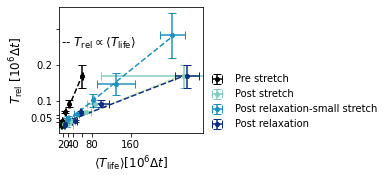

In [18]:
fig,ax = plt.subplots(1,figsize = (5.5,2.6))
#print(len(LifeTime4),len(Tau25))
labels = ['Pre stretch','Post stretch','Post relaxation','Post relaxation-small stretch','Post relaxation-smaller stretch','Post relaxation-smallest stretch']



ax.errorbar(LifetimeOG,Tau102,yerr=Tau102Err,xerr = LifetimeOGErr,color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[0])
ax.plot(x1,m1*x1+b1,color = 'black',linestyle = '--')
ax.errorbar(LifeTime0,Tau102,yerr=Tau102Err,xerr = LifeTime0Err,color =clrs_5[1],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[1])
ax.plot(x2,m2*x2+b2,color = clrs_5[0],linestyle = '--')
ax.errorbar(LifeTime2,Tau76,yerr=Tau76Err_1,xerr = LifeTime2Err,color = clrs_5[3],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[3])
ax.plot(x4,m4*x4+b4,color = clrs_5[3],linestyle = '--')
ax.errorbar(LifeTime1,Tau102,yerr=Tau102Err_1,xerr = LifeTime1Err,color = clrs_5[5],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[2])
ax.plot(x3,m3*x3+b3,color = clrs_5[5],linestyle = '--')
text = r"-- $T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$"
ax.text(16,0.25,text,fontsize = 12)
ax.legend(frameon=False,loc = [1,0])
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)
ax.set_xlim(12,310)
ax.set_xticks([20,30,40,60,80,160],['20','','40','','80','160'])
ax.set_yticks([0.04,0.05,0.06,0.1,0.2,0.3],['','0.05','','0.1','0.2',''])
fig.tight_layout()


plotname = "Turnover_vs_Tlife_MultipleTimes.pdf"
fig.savefig(plotsdir+plotname)


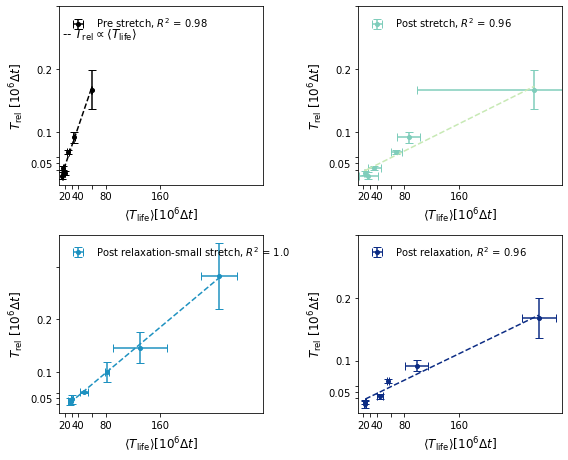

In [19]:
fig,ax = plt.subplots(2,2,figsize = (8,6.5))
#print(len(LifeTime4),len(Tau25))
labels = ['Pre stretch, $R^2$ = '+str(np.round(r1_squared,2)),'Post stretch, $R^2$ = '+str(np.round(r2_squared,2)),'Post relaxation, $R^2$ = '+str(np.round(r3_squared,2)),'Post relaxation-small stretch, $R^2$ = '+str(np.round(r4_squared,2))]



ax[0,0].errorbar(LifetimeOG,Tau102,yerr=Tau102Err,xerr = LifetimeOGErr,color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[0])
ax[0,0].plot(x1,m1*x1+b1,color = 'black',linestyle = '--')
ax[0,1].errorbar(LifeTime0,Tau102,yerr=Tau102Err,xerr = LifeTime0Err,color =clrs_5[1],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[1])
ax[0,1].plot(x2,m2*x2+b2,color = clrs_5[0],linestyle = '--')
ax[1,0].errorbar(LifeTime2,Tau76,yerr=Tau76Err_1,xerr = LifeTime2Err,color = clrs_5[3],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[3])
ax[1,0].plot(x4,m4*x4+b4,color = clrs_5[3],linestyle = '--')
ax[1,1].errorbar(LifeTime1,Tau102,yerr=Tau102Err_1,xerr = LifeTime1Err,color = clrs_5[5],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = labels[2])
ax[1,1].plot(x3,m3*x3+b3,color = clrs_5[5],linestyle = '--')
text = r"-- $T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$"
ax[0,0].text(16,0.25,text,fontsize = 12)

#ax.set_xscale('log')
#ax.set_yscale('log')
for ii in range(2):
    for jj in range(2):
        ax[ii,jj].set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
        ax[ii,jj].set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)
        ax[ii,jj].set_xlim(12,310)
        ax[ii,jj].set_xticks([20,30,40,60,80,160],['20','','40','','80','160'])
        ax[ii,jj].set_yticks([0.04,0.05,0.06,0.1,0.2,0.3],['','0.05','','0.1','0.2',''])
        ax[ii,jj].legend(frameon=False,loc = 'upper left')
fig.tight_layout()


plotname = "Turnover_vs_Tlife_MultipleTimes.pdf"
#fig.savefig(plotsdir+plotname)